In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
from pathlib import Path
import pickle
import subprocess

import matplotlib.pyplot as plt
import numpy as np
from openmm.app import PDBFile
from openbabel import pybel
import pandas as pd
from pdbfixer import PDBFixer

import sciapi
import scids
import scifile
import scishow

Define paths for storing intermediate results:

In [3]:
project_id = "3w32"

cache_dir = Path(f".tmp/{project_id}")
assert " " not in str(cache_dir), "autogrid does not accept whitespace in paths"
pdb_filepath_raw = cache_dir / "receptor_raw.pdb"
pdb_filepath_fixed = cache_dir / "receptor_fixed.pdb"
pdb_filepath_apo = cache_dir / "receptor_fixed_apo.pdb"
pdbqt_filepath = cache_dir / "receptor.pdbqt"
pockets_filepath = cache_dir / "pockets.pkl"
autogrid_dirpath = cache_dir/ "autogrid"
autogrid_common_path = autogrid_dirpath / project_id
gpf_filepath = autogrid_common_path.with_suffix(".gpf")
cache_dir.mkdir(exist_ok=True, parents=True)
autogrid_dirpath.mkdir(exist_ok=True, parents=True)

## Structure Preparation

Obtain a PDB file:

In [4]:
pdb_id = project_id

if not pdb_filepath_raw.is_file():
    pdb_file_content = sciapi.pdb.file.entry(pdb_id=pdb_id, file_format="pdb")
    pdb_filepath_raw.write_bytes(pdb_file_content)

Fix the PDB file:

In [5]:
if not pdb_filepath_fixed.is_file():
    fixer = PDBFixer(filename=str(pdb_filepath_raw))
    fixer.findMissingResidues()
    fixer.findNonstandardResidues()
    fixer.replaceNonstandardResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(7.0)
    PDBFile.writeFile(fixer.topology, fixer.positions, open(pdb_filepath_fixed, 'w'))

We store one fixed PDB with ligands, and one without.
The one with ligands is used later as reference for visualization and validation.
The one without ligands is used to create a PDBQT file for AutoGrid:

In [6]:
if not pdb_filepath_apo.is_file():
    fixer = PDBFixer(filename=str(pdb_filepath_fixed))
    fixer.removeHeterogens(False)
    PDBFile.writeFile(fixer.topology, fixer.positions, open(pdb_filepath_apo, 'w'))

Create the PDBQT file from the cleaned and fixed PDB file:

In [7]:
if not pdbqt_filepath.is_file():
    molecule = next(pybel.readfile("pdb", str(pdb_filepath_apo)))
    molecule.calccharges("gasteiger")
    molecule.write(
        format="pdbqt",
        filename=str(pdbqt_filepath),
        overwrite=True,
        opt={"r": None, "n": None, "p": None, "h": None},
    )


Read the created PDBQT file (used later for atom type references):

In [8]:
pdbqt_file = scifile.autodock_pdbqt.read(pdbqt_filepath)

/Volumes/T7/repo/gh/aariam/opencadd/scifile/pkg/src/scifile/pdb/parser.py:144: UserWarning: Error parsing record remark: invalid literal for int() with base 10: np.str_('Na')
  warnings.warn(
/Volumes/T7/repo/gh/aariam/opencadd/scifile/pkg/src/scifile/pdb/parser.py:144: UserWarning: Error parsing record cryst1: 'NoneType' object is not subscriptable
  warnings.warn(


## Binding Site Detection

Use DoGSiteScorer to detect binding sites (this is the longest step, taking ca. 1-2 min):

In [9]:
if not pockets_filepath.is_file():
    protplus_upload_results = sciapi.proteinsplus().upload_pdb(pdb_filepath_fixed.read_bytes())
    dogsite_results = sciapi.proteinsplus().dogsite(
        pdb_id=protplus_upload_results.dummy_pdb_id,
        algorithm="scorer",
    )
    binding_sites = dogsite_results.full_data
    with open(pockets_filepath, "wb") as f:
        pickle.dump(binding_sites, f)
else:
    with open(pockets_filepath, "rb") as f:
        binding_sites = pickle.load(f)

Select the best binding pocket.
Here we select the binding pocket with a volume less than 1000 Å^3 and highest score:

In [10]:
binding_site_df = pd.DataFrame(binding_sites)
idx_selected_pocket = binding_site_df[binding_site_df["volume"] < 1000]["simpleScore"].idxmax()
binding_site_df.loc[idx_selected_pocket, "name"]

'P_0_0'

Read the volume map for the selected pocket:

In [11]:
pocket = scifile.mrc.read(binding_site_df.loc[idx_selected_pocket, "mrc"])
pocket

MrcFile(
   n_xyz      = [46 35 45]
   mode       = 2
   nstart_xyz = [24 58  4]
   m_xyz      = [45 34 44]
   cell_a     = [19.375101 14.638966 18.944544]
   cell_b     = [90. 90. 90.]
   map_xyz    = (1, 2, 3)
   dmin       = 0.0
   dmax       = 1.0
   dmean      = 0.14201518893241882
   ispg       = 1
   nsymbt     = 0
   extra      = b''
   exttyp     = ""
   nversion   = 0
   extra2     = b''
   origin     = [0. 0. 0.]
   rms        = 0.3490656614303589
   nlabl      = 1
   labels     = ["CCP4 File written with NAOMI."]
)

Create a `Grid` from the map data:

In [12]:
grid = scids.grid.from_shape_spacing_anchor(
    shape=pocket.n_xyz,
    spacing=pocket.grid_vectors[0][0],
    anchor_type="lower",
    anchor_coord=pocket.grid_origin,
)
grid

Grid(
  shape=[46 35 45],
  size=[19.37510109 14.63896527 18.94454329],
  spacings=[0.4305578 0.4305578 0.4305578],
  lower_bounds=[10.33338608 24.97235302  1.72223126],
  center=[20.02093663 32.29183565 11.1945029 ],
  upper_bounds=[29.70848717 39.61131829 20.66677455]
)

## Energy Calculation

We want to use this same grid for AutoGrid as well, but AutoGrid only accepts an odd number of points per axis (i.e. `npts` values must be all even).
So we pad this array along even-numbered axis to create a overlapping AutoGrid-compliant grid:

In [13]:
is_odd = pocket.n_xyz % 2
npts = np.where(is_odd, pocket.n_xyz - 1, pocket.n_xyz)
slices = tuple(np.where(is_odd, slice(None), slice(-1)))
grid_autogrid = scids.grid.from_shape_spacing_anchor(
    shape=npts+1,
    spacing=pocket.grid_vectors[0][0],
    anchor_type="lower",
    anchor_coord=pocket.grid_origin,
)
grid_autogrid

Grid(
  shape=[47 35 45],
  size=[19.80565889 14.63896527 18.94454329],
  spacings=[0.4305578 0.4305578 0.4305578],
  lower_bounds=[10.33338608 24.97235302  1.72223126],
  center=[20.23621553 32.29183565 11.1945029 ],
  upper_bounds=[30.13904497 39.61131829 20.66677455]
)

Create a Grid Parameter File (GPF) for AutoGrid:

In [14]:
if not gpf_filepath.is_file():
    gpf_file = scifile.autodock_gpf.from_spec(
        receptor=pdbqt_filepath,
        receptor_types=pdbqt_file.atom["autodock_atom_type"].unique(),
        npts=npts,
        spacing=grid_autogrid.spacings[0],
        gridcenter=grid_autogrid.center,
        output_path=autogrid_common_path
    )
    gpf_filepath.write_text(str(gpf_file))
else:
    gpf_file = scifile.autodock_gpf.read(gpf_filepath)


Gather the output map filepaths and corresponding field name (i.e. atom types) from the generated GPF:

In [15]:
map_filepaths = gpf_file.maps + (gpf_file.elecmap, gpf_file.dsolvmap)
field_names = [lig_type.lower() for lig_type in gpf_file.ligand_types] + ["e", "d"]

Run AutoGrid:

In [16]:
if not all(map_filepath.is_file() for map_filepath in map_filepaths):
    process = subprocess.run(
        args=["autogrid4", "-p", gpf_filepath],
        check=True,
    )

Read the generated maps:

In [17]:
maps = scifile.autodock_map.read(map_filepaths)
maps.field.shape

(9, 47, 35, 45)

Remove the padding to retrieve the original grid:

In [18]:
tensor = maps.field[:, *slices]
tensor.shape

(9, 46, 35, 45)

Create a `ToxelField`:

In [19]:
mif = scids.field.from_tensor_grid(
    tensor=np.expand_dims(tensor.transpose(1, 2, 3, 0), axis=0),
    grid=grid,
    names=field_names
)

Plot energy distributions:

In [20]:
field_colors = {
    "c":  [255, 165, 0],     # Hydrophobic (Orange)
    "a":  [128, 0, 128],     # Aromatic (Purple)
    "hd": [0, 255, 255],     # H-bond Donor (Cyan)
    "n":  [0, 0, 255],       # Non-Hbonding Nitrogen (Blue)
    "na": [30, 144, 255],    # H-bonding Nitrogen (Dodger Blue)
    "oa": [0, 128, 0],       # H-bonding Oxygen (Green)
    "sa": [255, 20, 147],    # H-bonding Sulphur (Deep Pink)
    "e":  [255, 0, 0],       # Electrostatic (Red)
    "d":  [255, 215, 0],     # Desolvation (Gold)
}

In [21]:
def plot_histograms_by_last_axis(
    arr, names=None, colors=None, bins=50,
    bin_range=None, max_cols=4, figsize_per_plot=(4, 3), log_scale=True
):
    """
    Plot histograms for each slice along the last axis of a 4D array.

    Parameters:
        arr (np.ndarray): Shape (nx, ny, nz, na)
        names (list of str): Optional titles per histogram.
        colors (list of RGB tuples): Optional colors for each histogram.
        bins (int): Number of histogram bins.
        bin_range (tuple): (min, max) range for histogram bins.
        max_cols (int): Max columns in subplot grid.
        figsize_per_plot (tuple): Size (width, height) per subplot.
        log_scale (bool): Whether to apply log scale to y-axis.
    """
    if arr.ndim != 4:
        raise ValueError(f"Expected 4D array, got {arr.shape}")

    na = arr.shape[-1]

    if names is None:
        names = [f"Index {i}" for i in range(na)]
    elif len(names) != na:
        raise ValueError("Length of `names` must match last dimension of array")

    if colors is None:
        colors = ['steelblue'] * na
    elif len(colors) != na:
        raise ValueError("Length of `colors` must match last dimension of array")

    # Normalize RGB values if needed
    colors = [tuple(c / 255 if isinstance(c, int) else c for c in color) for color in colors]

    ncols = min(na, max_cols)
    nrows = math.ceil(na / ncols)
    figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

    for i in range(na):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        data = arr[..., i].ravel()

        ax.hist(data, bins=bins, range=bin_range, color=colors[i], edgecolor='black')
        ax.set_title(names[i])
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        if log_scale:
            ax.set_yscale('log')

    # Turn off unused subplots
    for j in range(na, nrows * ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r][c])

    fig.tight_layout()
    plt.show()


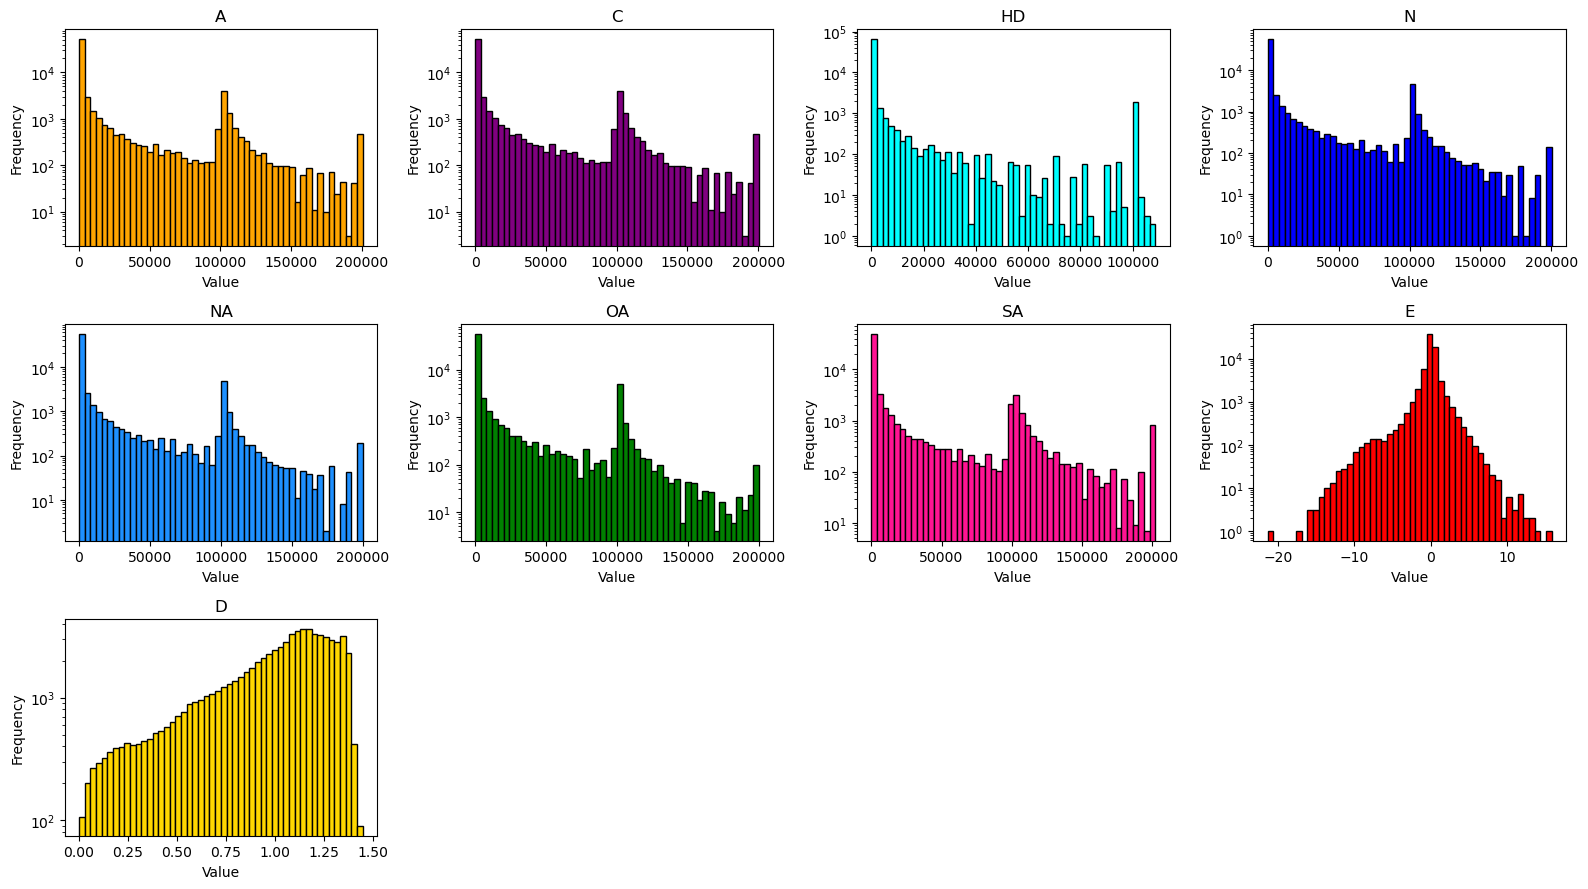

In [22]:
plot_histograms_by_last_axis(arr=mif.tensor[0], names=[name.upper() for name in field_names], colors=[tuple(c / 255 for c in rgb) for rgb in field_colors.values()])

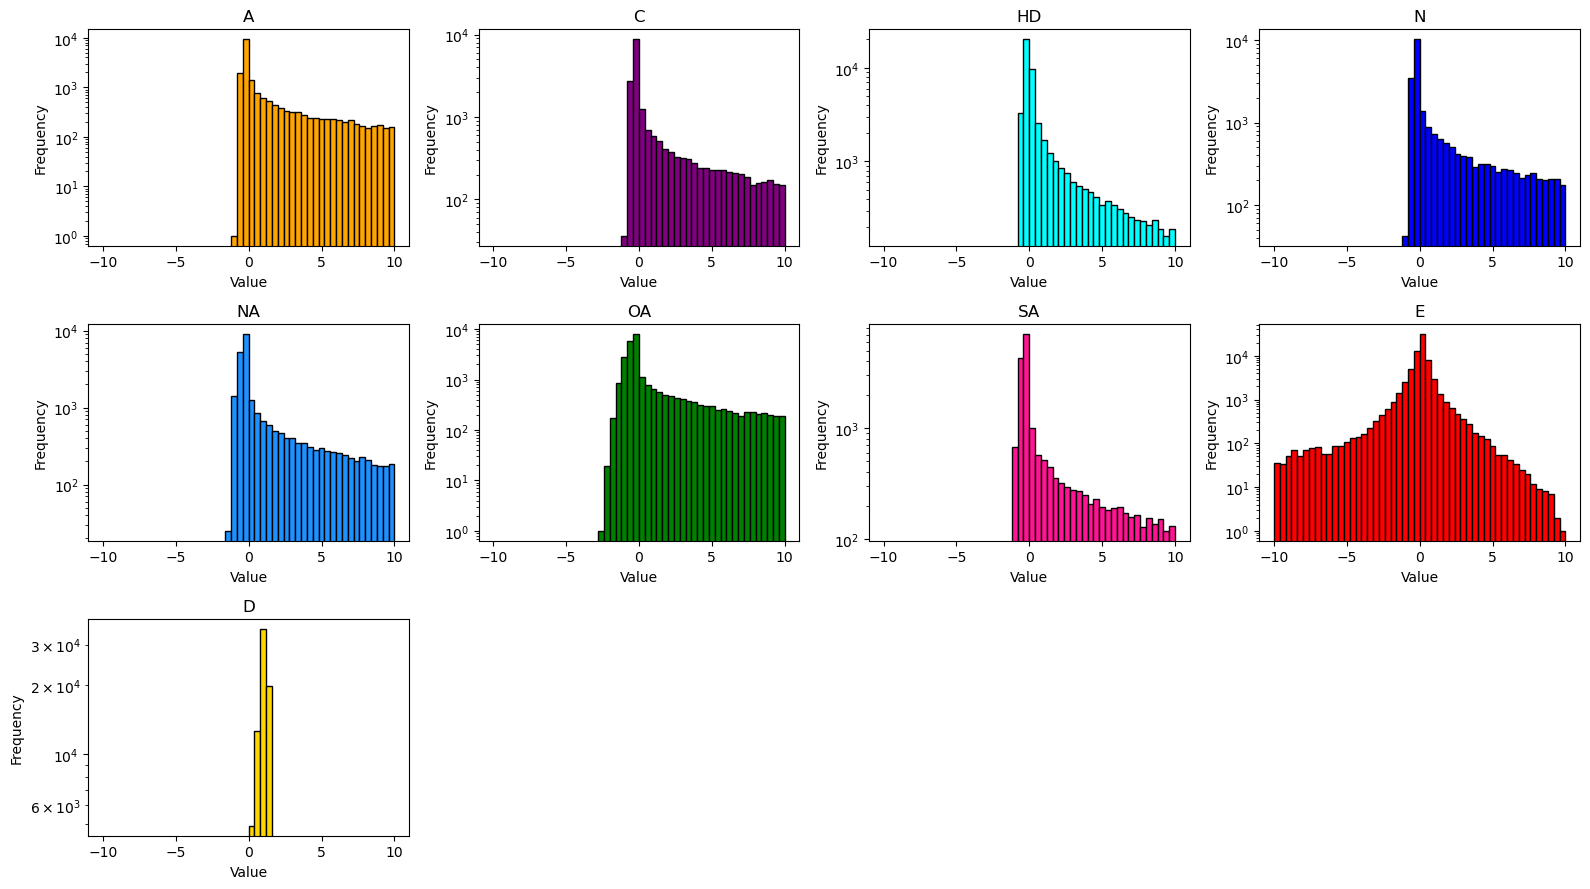

In [23]:
plot_histograms_by_last_axis(arr=mif.tensor[0], names=[name.upper() for name in field_names], colors=[tuple(c / 255 for c in rgb) for rgb in field_colors.values()], bin_range=(-10,10))

## Point Selection

Use the pocket volume as a mask and set everything outside of it equal zero:

In [24]:
tensor[:, pocket.data == 0] = 0

Visualize the fields:

In [25]:
nw = scishow.nglview.NGLWidget()
nw.add_component(str(pdb_filepath_fixed))
# Add the pocket
nw.add_volume(
    pocket.data,
    basis=pocket.grid_vectors,
    origin=pocket.grid_origin,
    name="pocket",
    representation_params=scishow.nglview.SurfaceRepresentationParameters(lazy=True, opacity=1, contour=True)
)
# Add the fields
for field_idx, field_name in enumerate(field_names):
    field_ = tensor[field_idx]
    nw.add_volume(
        field_,
        basis=mif.grid.unit_vectors,
        origin=mif.grid.lower_bounds,
        name=field_name,
        representation_params=scishow.nglview.SurfaceRepresentationParameters(
            lazy=True, opacity=1, visible=False, contour=True, isolevel=0, isolevel_type="value",
            isolevel_scroll=True, use_worker=True, color_value=f"rgb({", ".join(map(str,field_colors[field_name]))})"
        )
    )
nw.display(gui=True)


ThemeManager()

NGLWidget(gui_style='ngl')